Project root added to sys.path
Contents: ['.ipynb_checkpoints', 'data', 'experiments', 'folder_structure.ipynb', 'notebooks', 'reports', 'requirements.txt', 'src']
Loading: C:\Users\Arafat\Desktop\IMA Project\data\processed\features\ColorHists\ColorHists_features.npz
X_all shape: (12444, 96)
y_all shape: (12444,)
Explained variance ratios: [0.1215355  0.10242298]


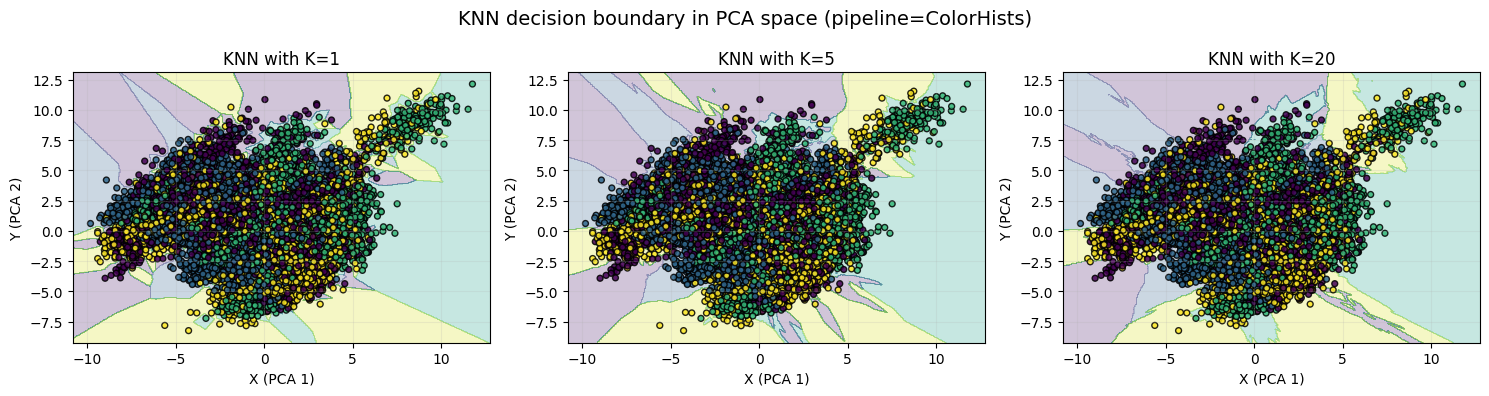

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import os
import sys


project_root = r"C:\Users\Arafat\Desktop\IMA Project"
if project_root not in sys.path:
    sys.path.append(project_root)

# sanity check
print("Project root added to sys.path")
print("Contents:", os.listdir(project_root))

from src import config


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier


def plot_knn_decision_boundary_grid(X_2d, y_int, k_list=(1, 5, 20), main_title="KNN Decision Boundaries (2D)"):
    """
    Here I want to make decision boundary plots like the classic KNN figure.
    """
    # mesh settings
    x_min, x_max = X_2d[:, 0].min() - 1.0, X_2d[:, 0].max() + 1.0
    y_min, y_max = X_2d[:, 1].min() - 1.0, X_2d[:, 1].max() + 1.0
    step = 0.05 

    xx, yy = np.meshgrid(np.arange(x_min, x_max, step),
                         np.arange(y_min, y_max, step))

    fig, axes = plt.subplots(1, len(k_list), figsize=(5 * len(k_list), 4), squeeze=False)
    axes = axes[0]

    for ax, k_value in zip(axes, k_list):
        knn_model = KNeighborsClassifier(n_neighbors=k_value)
        knn_model.fit(X_2d, y_int)

        grid_points = np.c_[xx.ravel(), yy.ravel()]
        grid_pred = knn_model.predict(grid_points).reshape(xx.shape)

        ax.contourf(xx, yy, grid_pred, alpha=0.25)

        # scatter points
        scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_int, s=18, edgecolor="k", alpha=0.85)

        ax.set_title(f"KNN with K={k_value}")
        ax.set_xlabel("X (PCA 1)")
        ax.set_ylabel("Y (PCA 2)")
        ax.grid(True, alpha=0.2)

    plt.suptitle(main_title, fontsize=14)
    plt.tight_layout()
    plt.show()



from src import config

pipe_name = "ColorHists"  
npz_path = os.path.join(config.FEATURES_DIR, pipe_name, f"{pipe_name}_features.npz")
print("Loading:", npz_path)

data = np.load(npz_path)
X_train = data["feat_train"]
X_val   = data["feat_val"]
X_test  = data["feat_test"]
y_train = data["y_train"]
y_val   = data["y_val"]
y_test  = data["y_test"]


X_all = np.vstack([X_train, X_val, X_test])
y_all = np.concatenate([y_train, y_val, y_test])

print("X_all shape:", X_all.shape)
print("y_all shape:", y_all.shape)


scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_all_scaled)

print("Explained variance ratios:", pca.explained_variance_ratio_)


plot_knn_decision_boundary_grid(
    X_2d=X_2d,
    y_int=y_all,
    k_list=(1, 5, 20),
    main_title=f"KNN decision boundary in PCA space (pipeline={pipe_name})"
)


### using only 2 classes

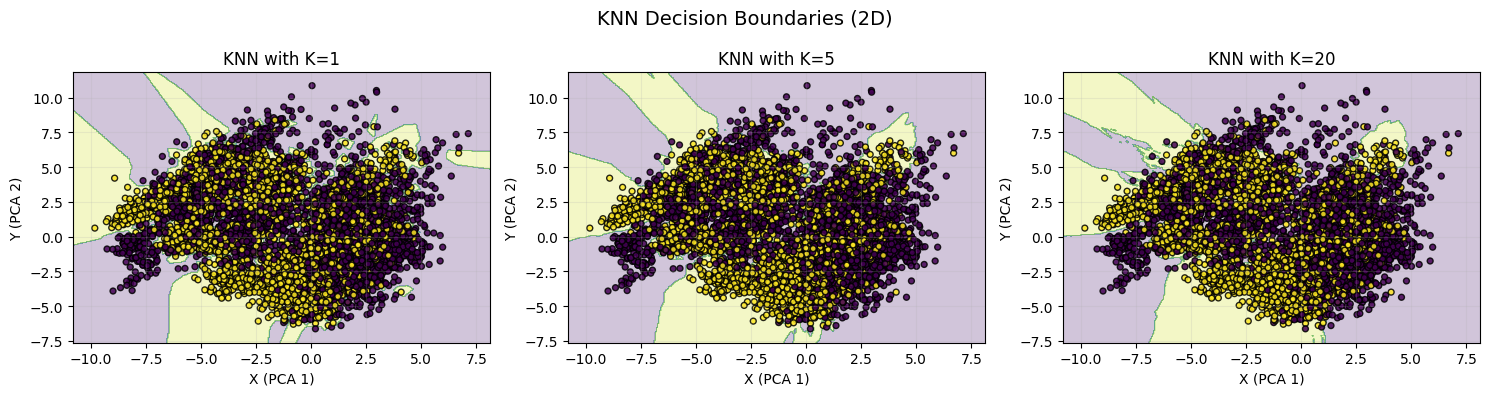

In [5]:
mask = (y_all == 0) | (y_all == 1)  
X_2d_small = X_2d[mask]
y_small = y_all[mask]
plot_knn_decision_boundary_grid(X_2d_small, y_small, k_list=(1,5,20))


### using a smaller subset

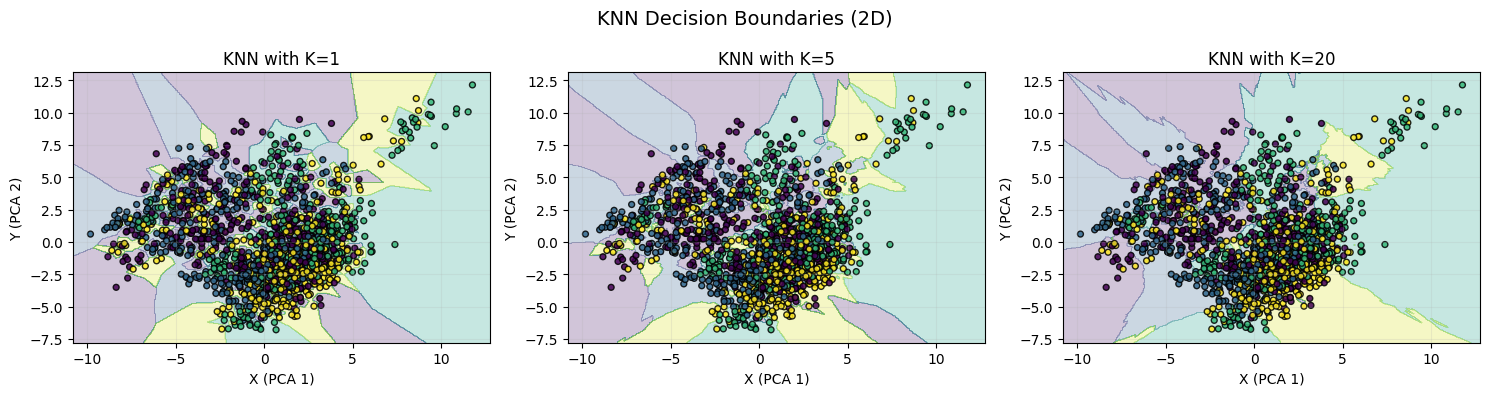

In [6]:
idx = np.random.choice(len(X_2d), size=1500, replace=False)
plot_knn_decision_boundary_grid(X_2d[idx], y_all[idx], k_list=(1,5,20))


Loading features from: C:\Users\Arafat\Desktop\IMA Project\data\processed\features\ColorHists\ColorHists_features.npz
X_all shape: (12444, 96) y_all shape: (12444,)
PCA explained variance ratio: [0.1215355  0.10242298]
Plotting points total: 1000 | per class target: 250


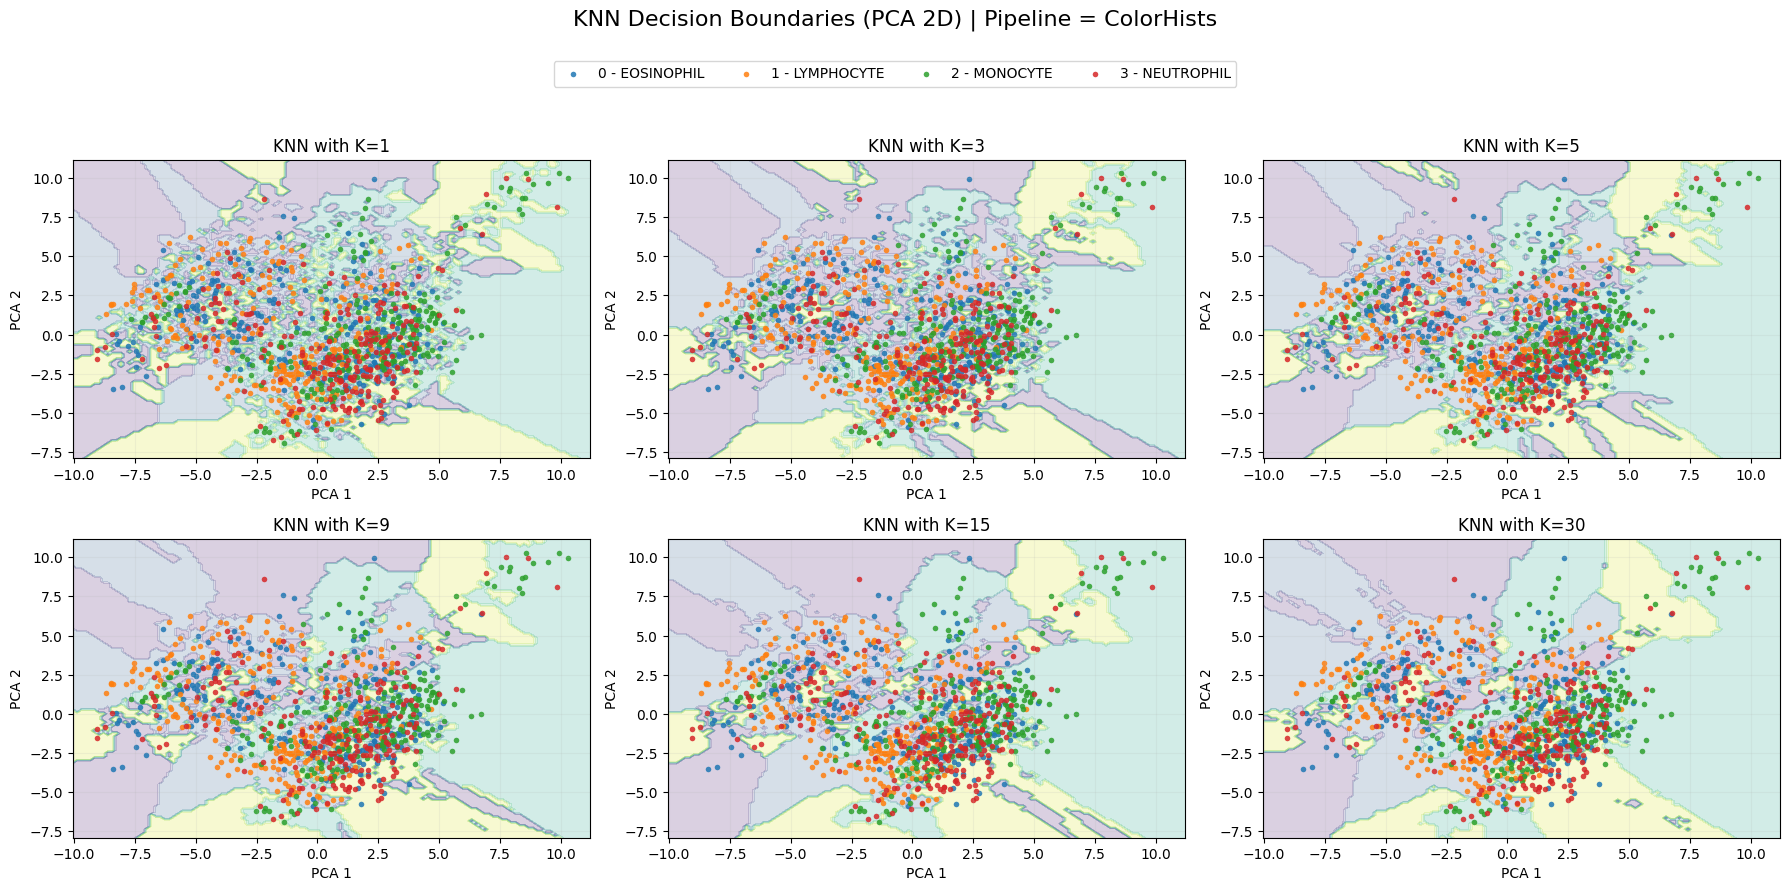

In [22]:

def plot_knn_boundaries_clean_4class(
    pipe_name="ColorHists",
    k_list=(1, 3, 5, 9, 15, 30),
    points_per_class=250,
    grid_step=0.18,
    alpha_bg=0.20,
    point_size=16,
    point_alpha=0.85,
    random_seed=42,
):

    rng = np.random.default_rng(random_seed)

    #load label mapping
    label_map_path = os.path.join(config.PROCESSED_DATA_DIR, "label_mapping.csv")
    label_map_df = pd.read_csv(label_map_path)
    class_id_to_name = dict(zip(label_map_df["class_id"], label_map_df["class_name"]))
    class_ids = sorted(class_id_to_name.keys())

    #Load features
    npz_path = os.path.join(config.FEATURES_DIR, pipe_name, f"{pipe_name}_features.npz")
    print("Loading features from:", npz_path)
    data = np.load(npz_path)

    X_all = np.vstack([data["feat_train"], data["feat_val"], data["feat_test"]])
    y_all = np.concatenate([data["y_train"], data["y_val"], data["y_test"]])

    print("X_all shape:", X_all.shape, "y_all shape:", y_all.shape)

    # Scale + PCA
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_all)

    pca = PCA(n_components=2, random_state=random_seed)
    X_2d = pca.fit_transform(X_scaled)

    print("PCA explained variance ratio:", pca.explained_variance_ratio_)

    # Balanced subsample for plotting
    chosen_indices = []
    for cid in class_ids:
        idxs = np.where(y_all == cid)[0]
        picked = rng.choice(idxs, size=min(points_per_class, len(idxs)), replace=False)
        chosen_indices.append(picked)

    chosen_indices = np.concatenate(chosen_indices)
    X_plot = X_2d[chosen_indices]
    y_plot = y_all[chosen_indices]

    print("Plotting points total:", len(y_plot),
          "| per class target:", points_per_class)

    # Mesh grid
    x_min, x_max = X_plot[:, 0].min() - 1.0, X_plot[:, 0].max() + 1.0
    y_min, y_max = X_plot[:, 1].min() - 1.0, X_plot[:, 1].max() + 1.0

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, grid_step),
        np.arange(y_min, y_max, grid_step)
    )
    grid_points = np.c_[xx.ravel(), yy.ravel()]

    # Plotting
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    axes = axes.ravel()

    for ax, k_value in zip(axes, k_list):
        knn = KNeighborsClassifier(n_neighbors=k_value)
        knn.fit(X_2d, y_all)

        Z = knn.predict(grid_points).reshape(xx.shape)
        ax.contourf(xx, yy, Z, alpha=alpha_bg)

        for cid in class_ids:
            mask = (y_plot == cid)
            ax.scatter(
                X_plot[mask, 0],
                X_plot[mask, 1],
                s=point_size,
                alpha=point_alpha,
                label=f"{cid} - {class_id_to_name[cid]}",
                linewidths=0
            )

        ax.set_title(f"KNN with K={k_value}")
        ax.set_xlabel("PCA 1")
        ax.set_ylabel("PCA 2")
        ax.grid(True, alpha=0.15)

  
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=4,
        frameon=True,
        bbox_to_anchor=(0.5, 0.935)
    )


    fig.suptitle(
        f"KNN Decision Boundaries (PCA 2D) | Pipeline = {pipe_name}",
        fontsize=16,
        y=0.985
    )


    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()



plot_knn_boundaries_clean_4class(
    pipe_name="ColorHists",
    k_list=(1, 3, 5, 9, 15, 30),
    points_per_class=250,
    grid_step=0.18
)
